# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [1]:
!pip install datasets


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

/Users/armantsaturian/.pyenv/versions/3.12.6/envs/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [2]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



In [3]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [4]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [5]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [6]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)

### **Part 1 - Implement SGD for Logistic Regression in PyTorch**

####**Task 1.1. - Implement Logistic Regression in PyTorch (2 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [8]:
X_train.shape

(6920, 10000)

In [10]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # TODO:
        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros(n_features) # shape (n_features)

        elif init == "random":
            w = torch.rand(n_features) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")
        b = torch.tensor(0.0)
        # TODO:
        # Wrap weights and bias using nn.Parameter
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(b)

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        # TODO:
        logits = x @ self.w.view(-1,1) + self.b # column vector as the result
        probs = torch.sigmoid(logits)
        # print(logits, probs)
        return probs # column

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        # TODO:
        probs = self.forward(x)
        preds = (probs > 0.5).float()

        return preds

####**Task 1.2 - Train Logistic Regression with SGD Using Your Previous Implementations (1 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use your LogisticRegression class from Task 1.1.

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [11]:
def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute the binary cross-entropy loss for a logistic regression model.
    You'll need it for the function below

    binary classiciatoin
    if y_true = 1: we maximise y_pred, minimise -log(y_pred)
    elif y_true = 0: we maximise (1 - y_pred), aka minimise -log(1-y_pred)
    binary cross entropy: min loss = -log(y_pred) * y_true - log(1-y_pred) * (1 - y_true)
    """
    epsilon = 1e-15
    # clamp y_pred for numerical stability
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    # Compute binary log-loss remmber that the loss should provide a scalar value for the backwards to work
    loss = - torch.log(y_pred) * y_true - torch.log(1-y_pred) * (1 - y_true)
    # print('loss shapes:', 'ypred:',y_pred.shape, 'ytrue:',y_true.shape, "loss:",loss.shape)
    return loss.mean()

In [12]:
def accuracy(y_pred, y_true):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    return (tp + tn) / (tp + tn + fp + fn)

def f1_score(y_pred, y_true):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    # precision = tp / ()
    return

In [13]:
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty='none',          # For Task 1.5 : options: 'none', 'l1', 'l2'
    reg_lambda=0.0,          # For Task 1.5
    metric='accuracy',
    print_metrics=False,
    loss_plot=False,
    patience=None            # Early stopping: stop if val_loss doesn't improve for this many epochs
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch
    patience : int or None
        If set, stop training when val_loss hasn't improved for this many consecutive epochs

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """


    # 1. Convert data to tensors

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # convert to column

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1) # convert to column

    n_samples, n_features = X_train_tensor.shape


    # 2. Initialize model

    model = LogisticRegression(n_features=n_features, init=init)


    # 3. Create optimizer

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)


    # 4. Create logs

    history = []      # save w, b after each batch update
    epoch_log = []    # save epoch-level loss and metrics

    # Early stopping state
    best_val_loss = float('inf')
    wait = 0

    # 5. Training loop

    for epoch in range(epochs):

        # TODO:
        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            # TODO:
            # Select mini-batch
            X_batch = X_train_epoch[start : end]
            y_batch = y_train_epoch[start : end]

            # TODO:
            # Forward pass
            y_pred = model(X_batch)

            # TODO:
            # Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # TODO in task 1.5:
            # Add regularization if needed
            # penalty == 'l1'  -> reg_lambda * ||w||_1
            # penalty == 'l2'  -> reg_lambda * ||w||_2^2
            # penalty == 'none' -> no regularization
            if penalty == 'l1':
               reg_term = reg_lambda * torch.sum(torch.abs(model.w))
            elif penalty == 'l2':
               reg_term = reg_lambda * torch.sum(model.w ** 2)
            else:
               reg_term = 0

            loss = data_loss + reg_term

            # TODO:
            # Backward pass and optimization step

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # TODO:
            # Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })


        # 6. Epoch-level evaluation

        with torch.no_grad():

            # TODO:
            # Compute probabilities on full train/val sets
            y_pred_train = model(X_train_tensor)
            y_pred_val = model(X_val_tensor)

            # TODO:
            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # TODO:
            # Convert probabilities to binary predictions
            y_hat_train = (y_pred_train > 0.5).float()
            y_hat_val = (y_pred_val  > 0.5).float()

            # TODO:
            # Compute evaluation metric
            if metric == 'f1':
                train_metric = ...
                val_metric = ...
            else:
                train_metric = accuracy(y_hat_train, y_train_tensor)
                val_metric = accuracy(y_hat_val, y_val_tensor)

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

        if loss_plot:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(8, 4))
            epochs_so_far = [e['epoch'] + 1 for e in epoch_log]
            ax.plot(epochs_so_far, [e['train_loss'] for e in epoch_log], color='tab:blue', label='Train Loss')
            ax.plot(epochs_so_far, [e['val_loss'] for e in epoch_log], color='tab:orange', label='Val Loss')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.set_title(f'Training & Validation Loss  |  Train acc: {train_metric:.4f}  |  Val acc: {val_metric:.4f}')
            ax.legend()
            ax.grid(True)
            display(fig)
            plt.close(fig)

        # Early stopping check
        if patience is not None:
            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    if print_metrics:
                        print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                    break

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log

####**Task 1.3 - Experiments (2 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


In [99]:
PATIENCE = 42 # epochs without val_loss improvement for early stopping
EPOCHS_DEFAULT = 2000

learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

# Run all combinations
results = {}
for bs in (batch_sizes):
    for lr in learning_rates:
        print(f"Training bs={bs}, lr={lr} ...")
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            init='zeros', lr=lr, batch_size=bs, epochs=EPOCHS_DEFAULT,
            patience=PATIENCE
        )
        stopped = len(epoch_log)
        print(f"  -> stopped at epoch {stopped}")
        results[(bs, lr)] = epoch_log

Training bs=50, lr=0.01 ...
  -> stopped at epoch 1856
Training bs=50, lr=0.03 ...
  -> stopped at epoch 642
Training bs=50, lr=0.1 ...
  -> stopped at epoch 234
Training bs=50, lr=0.3 ...
  -> stopped at epoch 111
Training bs=50, lr=1.0 ...
  -> stopped at epoch 59
Training bs=100, lr=0.01 ...
  -> stopped at epoch 2000
Training bs=100, lr=0.03 ...
  -> stopped at epoch 1095
Training bs=100, lr=0.1 ...
  -> stopped at epoch 387
Training bs=100, lr=0.3 ...
  -> stopped at epoch 174
Training bs=100, lr=1.0 ...
  -> stopped at epoch 70
Training bs=200, lr=0.01 ...
  -> stopped at epoch 2000
Training bs=200, lr=0.03 ...
  -> stopped at epoch 2000
Training bs=200, lr=0.1 ...
  -> stopped at epoch 753
Training bs=200, lr=0.3 ...
  -> stopped at epoch 283
Training bs=200, lr=1.0 ...
  -> stopped at epoch 117


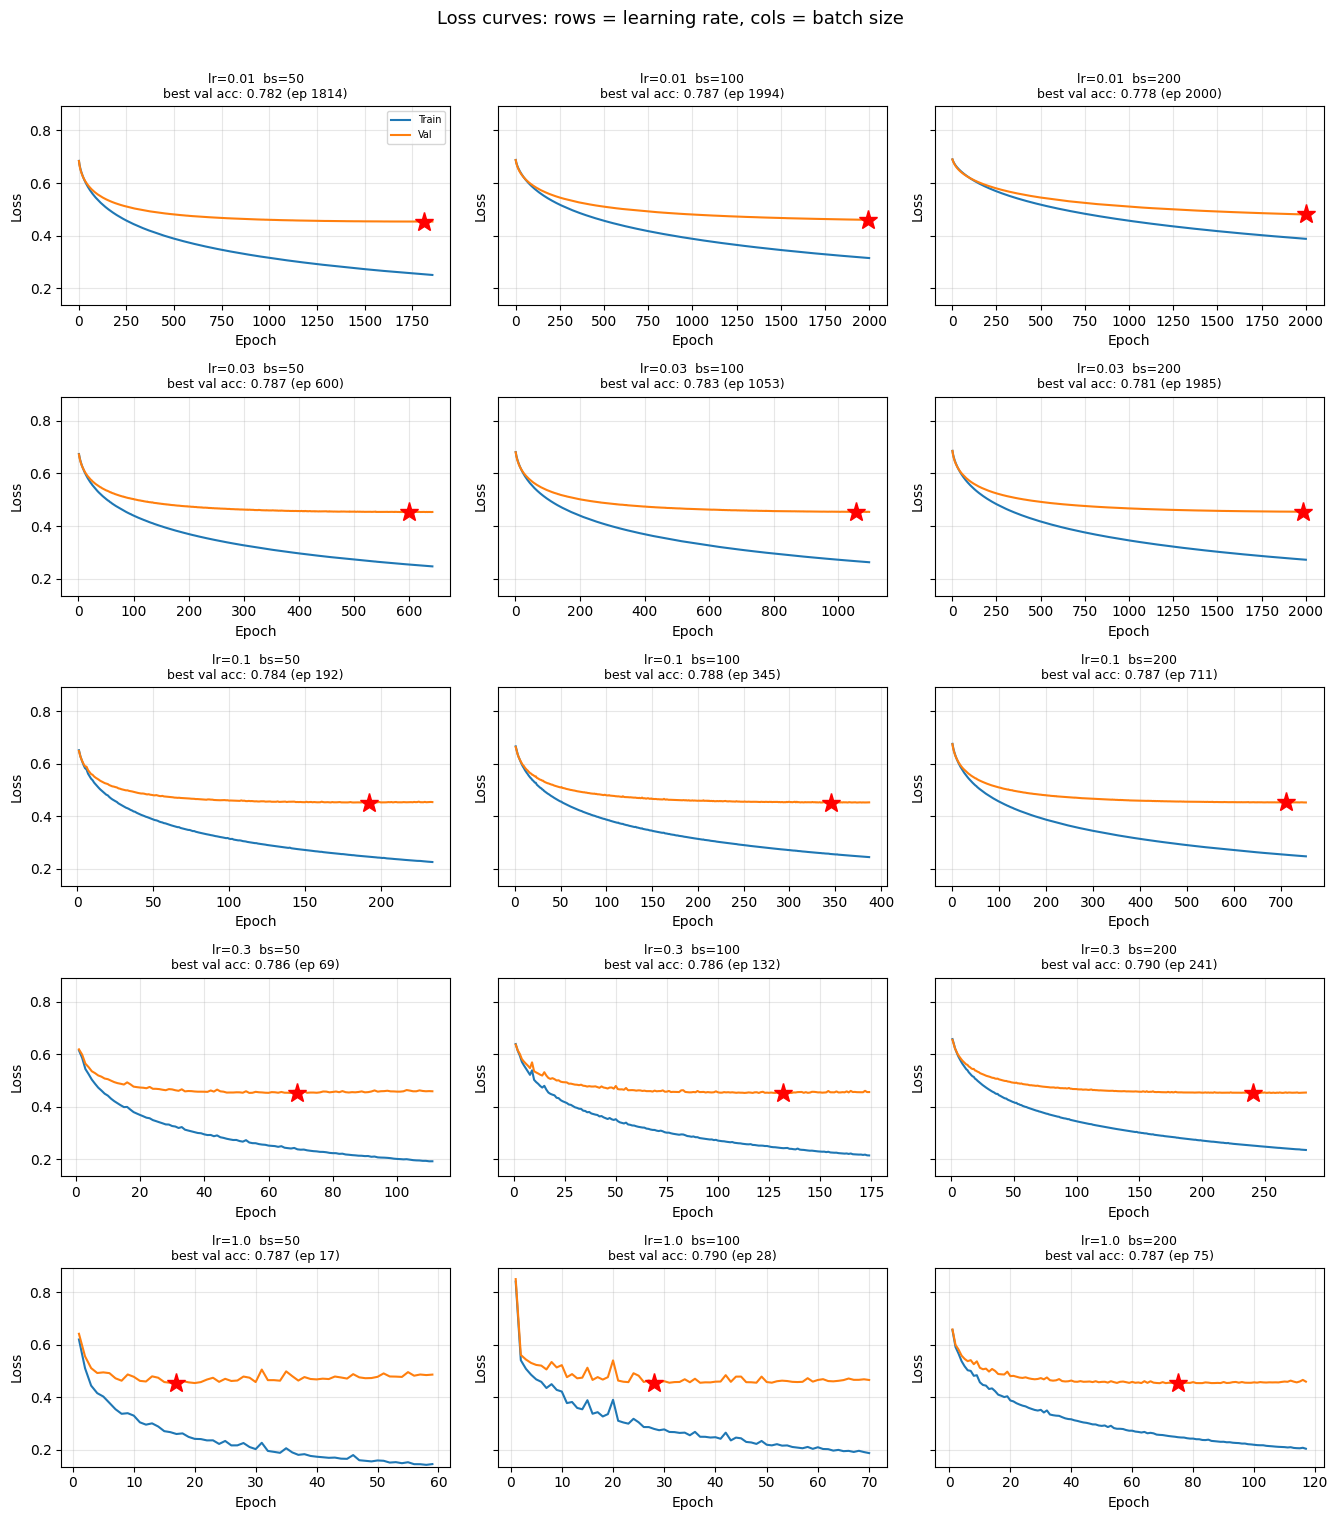

,lr,batch_size,best_val_acc,min_val_loss,best_epoch,total_epochs
rank,,,,,,
1,1.00,100,0.790138,0.45457,28,70
2,0.30,200,0.790138,0.45287,241,283
3,0.10,100,0.787844,0.45277,345,387
4,0.03,50,0.786697,0.45307,600,642
5,1.00,50,0.786697,0.45307,17,59
6,0.01,100,0.786697,0.45993,1994,2000
7,0.10,200,0.786697,0.45303,711,753
8,1.00,200,0.786697,0.45315,75,117
9,0.30,50,0.785550,0.45254,69,111


In [101]:
# Compute global y-axis limits across all experiments (ignoring NaN)
all_losses = []
for log in results.values():
    for e in log:
        if not (np.isnan(e['train_loss']) or np.isnan(e['val_loss'])):
            all_losses.extend([e['train_loss'], e['val_loss']])
y_min = min(all_losses) * 0.95
y_max = max(all_losses) * 1.05

# Plot grid: rows = learning rates (5), cols = batch sizes (3)
fig, axes = plt.subplots(len(learning_rates), len(batch_sizes),
                         figsize=(4.5 * len(batch_sizes), 3 * len(learning_rates)),
                         sharex=False, sharey=True)

for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):
        ax = axes[i][j]
        log = results[(bs, lr)]
        epochs_range = [e['epoch'] + 1 for e in log]
        val_losses = [e['val_loss'] for e in log]
        ax.plot(epochs_range, [e['train_loss'] for e in log], color='tab:blue', label='Train')
        ax.plot(epochs_range, val_losses, color='tab:orange', label='Val')

        # Find best val loss epoch (ignoring NaN)
        valid = [(k, v) for k, v in enumerate(val_losses) if not np.isnan(v)]
        if valid:
            best_idx, best_val_loss = min(valid, key=lambda x: x[1])
            best_epoch = epochs_range[best_idx]
            best_val_acc = log[best_idx]['val_metric']
            ax.plot(best_epoch, best_val_loss, '*', color='red', markersize=14, zorder=5)
            ax.set_title(f'lr={lr}  bs={bs}\nbest val acc: {best_val_acc:.3f} (ep {best_epoch})', fontsize=9)
        else:
            ax.set_title(f'lr={lr}  bs={bs}\nNaN', fontsize=9)

        ax.set_ylim(y_min, y_max)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

fig.suptitle('Loss curves: rows = learning rate, cols = batch size', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Summary table sorted by best val accuracy (descending) ---
import pandas as pd

rows = []
for (bs, lr), log in results.items():
    val_losses = [e['val_loss'] for e in log]
    valid = [(k, v) for k, v in enumerate(val_losses) if not np.isnan(v)]
    if valid:
        best_idx, min_val_loss = min(valid, key=lambda x: x[1])
        best_val_acc = float(log[best_idx]['val_metric'])
        best_epoch = log[best_idx]['epoch'] + 1
    else:
        min_val_loss, best_val_acc, best_epoch = float('nan'), float('nan'), None
    rows.append({
        'lr': lr,
        'batch_size': bs,
        'best_val_acc': best_val_acc,
        'min_val_loss': round(min_val_loss, 5),
        'best_epoch': best_epoch,
        'total_epochs': len(log)
    })

df = pd.DataFrame(rows).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
df.index += 1  # rank starting from 1
df.index.name = 'rank'
display(df)

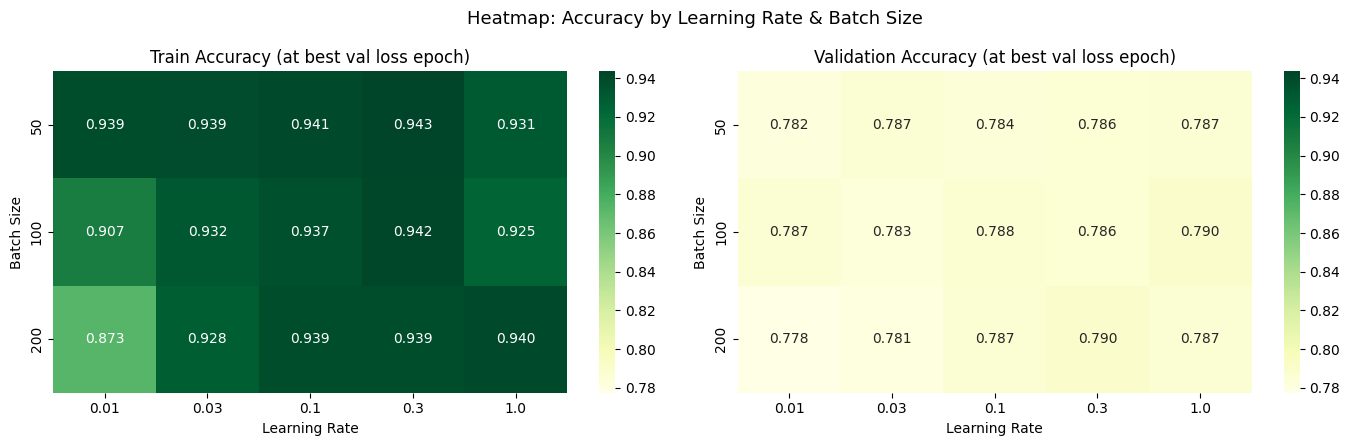

In [102]:
import seaborn as sns

# Build 2D arrays for heatmaps: rows = batch_sizes, cols = learning_rates
train_acc_grid = np.zeros((len(batch_sizes), len(learning_rates)))
val_acc_grid = np.zeros((len(batch_sizes), len(learning_rates)))

for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        log = results[(bs, lr)]
        val_losses = [e['val_loss'] for e in log]
        valid = [(k, v) for k, v in enumerate(val_losses) if not np.isnan(v)]
        if valid:
            best_idx, _ = min(valid, key=lambda x: x[1])
            train_acc_grid[i, j] = float(log[best_idx]['train_metric'])
            val_acc_grid[i, j] = float(log[best_idx]['val_metric'])
        else:
            train_acc_grid[i, j] = float('nan')
            val_acc_grid[i, j] = float('nan')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

sns.heatmap(train_acc_grid, annot=True, fmt='.3f', cmap='YlGn',
            xticklabels=learning_rates, yticklabels=batch_sizes,
            ax=ax1, vmin=min(train_acc_grid.min(), val_acc_grid.min()),
            vmax=max(train_acc_grid.max(), val_acc_grid.max()))
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Batch Size')
ax1.set_title('Train Accuracy (at best val loss epoch)')

sns.heatmap(val_acc_grid, annot=True, fmt='.3f', cmap='YlGn',
            xticklabels=learning_rates, yticklabels=batch_sizes,
            ax=ax2, vmin=min(train_acc_grid.min(), val_acc_grid.min()),
            vmax=max(train_acc_grid.max(), val_acc_grid.max()))
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('Batch Size')
ax2.set_title('Validation Accuracy (at best val loss epoch)')

fig.suptitle('Heatmap: Accuracy by Learning Rate & Batch Size', fontsize=13)
plt.tight_layout()
plt.show()

---
# Thoughts and Analysis

Note: Please referency mostly ythe loss curves from training instead of heatmap. Beaucase heatmap shows only they resluting converged accuracy regardless of steps it took to get there. So use thegraphs where the best model for each training is marked with Red Star.

### 1.2. Metric. Why Accuracy?
- We have class balance and accuracy is simpler and suitable for such case.

### 1.3. Experiments.

**Convergance**
- All training setups converge to around 0.78-0.79 val accuracy given enough trainning time.
- Models converge faster with smaller batch sizes across all experiments (see trainnig loss curves across rows). e.g for LR=0.03 it took 600 epochs with batch_size=50 to converge, 1053 with batch_size=100 and 1985 with batch_size=200. Same for all the other experiments. Reason: we update the model parameters more frequently and translate learning faster. Though stability suffered. (see below). Why?
- Lower LR (0.01, 0.03) corresponded to longer training to converge (1000+ epochs). While larger lr (0.3, 1.0) required on avg 50-150 epochs to converge. This is seen across all experiments given fixed batch_size. Reason is obvious, we more agressively update the weights and move to loss local minima in less steps.

**Stability**
- Let's measure the Stability of Training by how the loss / accuracy changes from epoch to epoch. If the loss curve is smooth - we call the training "stable" / If the loss jumps massively from epoch to epoch we call the training less stable.
- Smaller batch size corresponds to less stable training than larger batch size. Best seen my experinets at LR 0.03 and LR 0.1 (last two rows). Intuition: by having larger batch_size we average out the outlier samples and the mean loss from epoch is more stable. while with small batch size, we can have a case when large percent for randomly selected batch are outliers and result in non optimal loss and non-optimal weights update.
- Smaller LR means better stability.

CAVEAT: our experiments all used different number of epochs so the curves are more smooth for experiments with larger epochs. How do i measure it properly???

**Final Performance**
- The best Val Accuracy we got is 0.79 for two models (LR=1.0, BS=100) and (LR=0.3, BS=200). But as mentioned earlier, all experiments converged to around the same val acc of ~0.78-0.79 with different number of epochs. And the difference in minimal. (LR=1.0, BS=100) is most efficnet in accuracy x amount of compute spent.
---

####**Task 1.4 — L1 Regularization and Sparsity (2 points)**



In this task, you will extend your implementation from Task 1.3 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

In [160]:
# Task 1.4 — Experiment 1: weight init × regularization mode comparison
weight_init_modes = ['zeros', 'random']
reg_modes = [('none', 0.0), ('l1', 1e-3), ('l2', 1e-3)]

l1_results = {}
for init_mode in weight_init_modes:
    for penalty, reg_lam in reg_modes:
        label = f"init={init_mode}, {penalty}(λ={reg_lam})"
        print(f"Training: {label} ...")
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            init=init_mode, lr=0.1, batch_size=100, epochs=500,
            penalty=penalty, reg_lambda=reg_lam
        )
        n_near_zero = int((np.abs(w) < 1e-7).sum())
        l1_results[(init_mode, penalty, reg_lam)] = {
            'w': w, 'b': b, 'history': history, 'epoch_log': epoch_log,
            'n_near_zero': n_near_zero
        }
        print(f"  -> epochs: {len(epoch_log)}, near-zero weights: {n_near_zero}/{len(w)}")

# Summary table
rows = []
for (init_mode, penalty, reg_lam), res in l1_results.items():
    log = res['epoch_log']
    val_losses = [e['val_loss'] for e in log]
    valid = [(k, v) for k, v in enumerate(val_losses) if not np.isnan(v)]
    if valid:
        best_idx, min_vl = min(valid, key=lambda x: x[1])
        best_val_acc = float(log[best_idx]['val_metric'])
        best_train_acc = float(log[best_idx]['train_metric'])
    else:
        min_vl, best_val_acc, best_train_acc = float('nan'), float('nan'), float('nan')
    rows.append({
        'init': init_mode,
        'penalty': penalty,
        'reg_lambda': reg_lam,
        'best_train_acc': round(best_train_acc, 4),
        'best_val_acc': round(best_val_acc, 4),
        'min_val_loss': round(min_vl, 5),
        'near_zero_weights': res['n_near_zero'],
        'epochs_run': len(log)
    })

df_l1 = pd.DataFrame(rows).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
df_l1.index += 1
df_l1.index.name = 'rank'
display(df_l1)

Training: init=zeros, none(λ=0.0) ...
  -> epochs: 500, near-zero weights: 0/10000
Training: init=zeros, l1(λ=0.001) ...
  -> epochs: 500, near-zero weights: 15/10000
Training: init=zeros, l2(λ=0.001) ...
  -> epochs: 500, near-zero weights: 0/10000
Training: init=random, none(λ=0.0) ...
  -> epochs: 500, near-zero weights: 0/10000
Training: init=random, l1(λ=0.001) ...
  -> epochs: 500, near-zero weights: 10/10000
Training: init=random, l2(λ=0.001) ...
  -> epochs: 500, near-zero weights: 0/10000


,init,penalty,reg_lambda,best_train_acc,best_val_acc,min_val_loss,near_zero_weights,epochs_run
rank,,,,,,,,
1,zeros,none,0.000,0.9399,0.7913,0.45264,0,500
2,random,none,0.000,0.9409,0.7878,0.45303,0,500
3,zeros,l2,0.001,0.8564,0.7787,0.50958,0,500
4,random,l2,0.001,0.8539,0.7729,0.50936,0,500
5,zeros,l1,0.001,0.7223,0.7328,0.56121,15,500
6,random,l1,0.001,0.7241,0.7248,0.56134,10,500


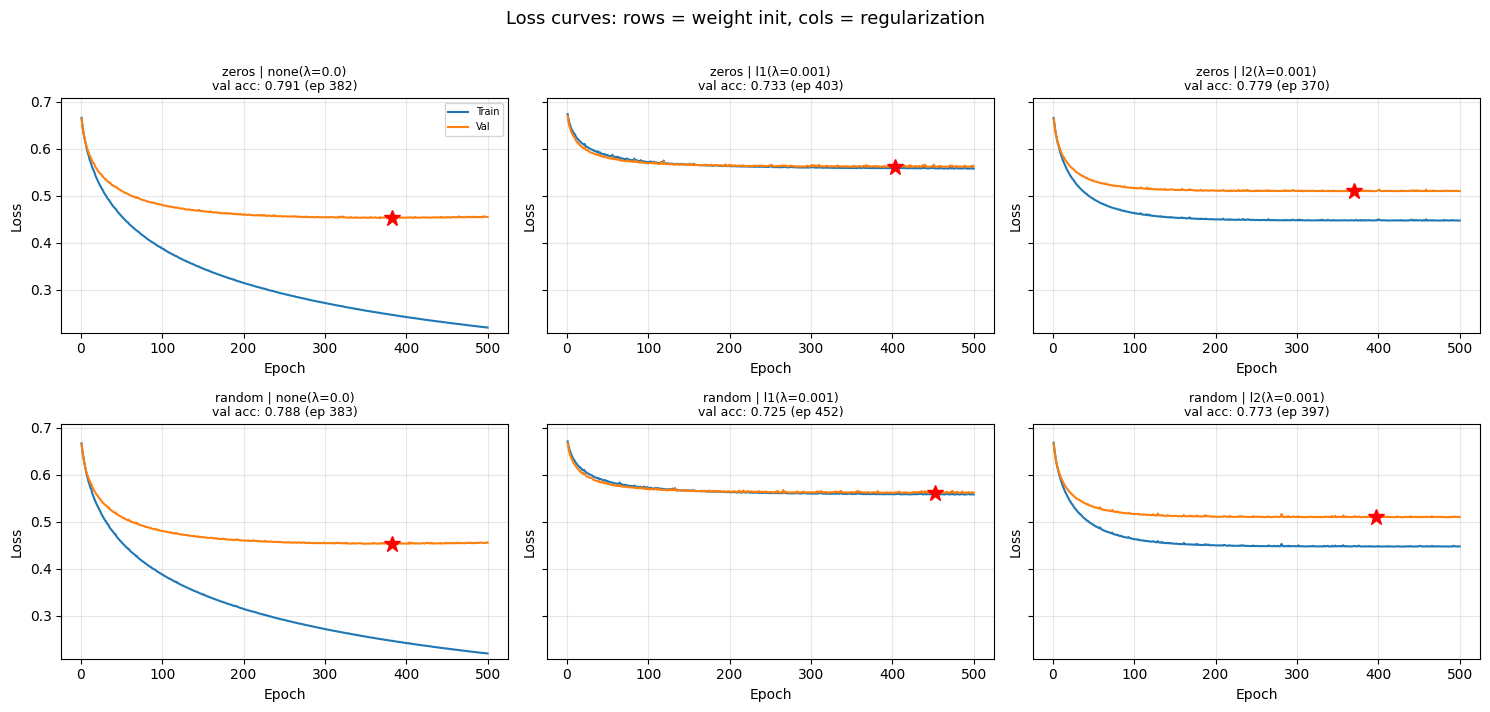

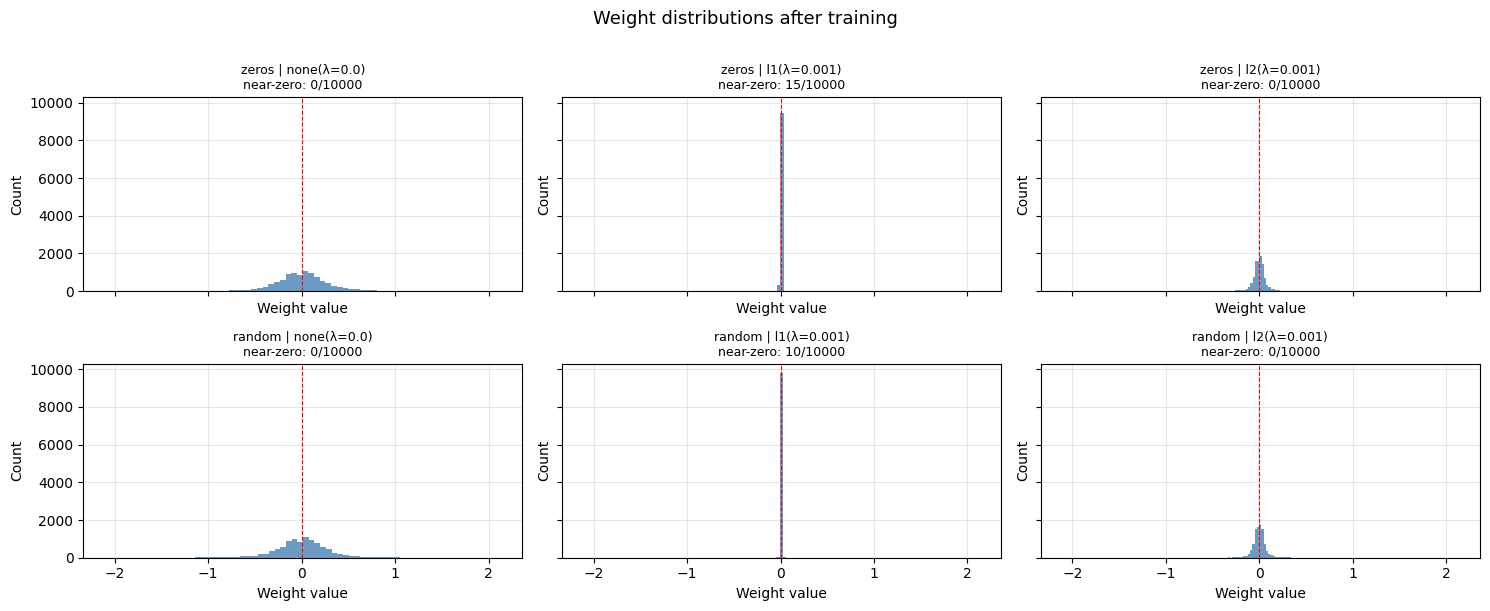

In [161]:
# --- Loss curves grid: rows = init mode, cols = penalty ---
fig, axes = plt.subplots(len(weight_init_modes), len(reg_modes),
                         figsize=(5 * len(reg_modes), 3.5 * len(weight_init_modes)),
                         sharey=True)

# Global y limits
all_l = []
for res in l1_results.values():
    for e in res['epoch_log']:
        if not (np.isnan(e['train_loss']) or np.isnan(e['val_loss'])):
            all_l.extend([e['train_loss'], e['val_loss']])
yl = (min(all_l) * 0.95, max(all_l) * 1.05)

for i, init_mode in enumerate(weight_init_modes):
    for j, (penalty, reg_lam) in enumerate(reg_modes):
        ax = axes[i][j]
        res = l1_results[(init_mode, penalty, reg_lam)]
        log = res['epoch_log']
        eps = [e['epoch'] + 1 for e in log]
        val_losses = [e['val_loss'] for e in log]

        ax.plot(eps, [e['train_loss'] for e in log], color='tab:blue', label='Train')
        ax.plot(eps, val_losses, color='tab:orange', label='Val')

        # Best val loss marker
        valid = [(k, v) for k, v in enumerate(val_losses) if not np.isnan(v)]
        if valid:
            best_idx, best_vl = min(valid, key=lambda x: x[1])
            ax.plot(eps[best_idx], best_vl, '*', color='red', markersize=12, zorder=5)
            acc = log[best_idx]['val_metric']
            ax.set_title(f'{init_mode} | {penalty}(λ={reg_lam})\nval acc: {acc:.3f} (ep {eps[best_idx]})', fontsize=9)
        else:
            ax.set_title(f'{init_mode} | {penalty}(λ={reg_lam})\nNaN', fontsize=9)

        ax.set_ylim(*yl)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

fig.suptitle('Loss curves: rows = weight init, cols = regularization', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Weight distribution histograms ---
fig, axes = plt.subplots(len(weight_init_modes), len(reg_modes),
                         figsize=(5 * len(reg_modes), 3 * len(weight_init_modes)),
                         sharex=True, sharey=True)

for i, init_mode in enumerate(weight_init_modes):
    for j, (penalty, reg_lam) in enumerate(reg_modes):
        ax = axes[i][j]
        res = l1_results[(init_mode, penalty, reg_lam)]
        weights = res['w']
        ax.hist(weights, bins=70, color='steelblue', edgecolor='none', alpha=0.8)
        ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
        nz = res['n_near_zero']
        ax.set_title(f'{init_mode} | {penalty}(λ={reg_lam})\nnear-zero: {nz}/{len(weights)}', fontsize=9)
        ax.set_xlabel('Weight value')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)

fig.suptitle('Weight distributions after training', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Observations on the first experiments:
- Models with Regularised loss have the train and val loss closer. The model is not overfitting on the train data.
- Reg models have not reached the val acc of nonregularised one. Because of high lambda selected. The model has large bias and low varience.
- We can already observe that L1 regularisation has a lot more close to 0 values in model weights than L2 or no regularisation.
- Zeros initialization had stronger performace across the board.
- No stability issues in neiter of experiments, no NaNs.

In [164]:
# Task 1.4 — Experiment 2: weight init × regularization mode comparison
weight_init_modes = ['zeros']
reg_modes = [('none', 0.0), ('l1', 1e-4),('l2', 1e-4), ('l1', 1e-3), ('l2', 1e-3), ('l1', 1e-2), ('l2', 1e-2), ('l1', 1e-1), ('l2', 1e-1)]

l1_results = {}
for init_mode in weight_init_modes:
    for penalty, reg_lam in reg_modes:
        label = f"init={init_mode}, {penalty}(λ={reg_lam})"
        print(f"Training: {label} ...")
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            init=init_mode, lr=0.1, batch_size=100, epochs=600,
            penalty=penalty, reg_lambda=reg_lam, patience=50
        )
        n_near_zero = int((np.abs(w) < 1e-7).sum())
        l1_results[(init_mode, penalty, reg_lam)] = {
            'w': w, 'b': b, 'history': history, 'epoch_log': epoch_log,
            'n_near_zero': n_near_zero
        }
        print(f"  -> epochs: {len(epoch_log)}, near-zero weights: {n_near_zero}/{len(w)}")


Training: init=zeros, none(λ=0.0) ...
  -> epochs: 446, near-zero weights: 0/10000
Training: init=zeros, l1(λ=0.0001) ...
  -> epochs: 382, near-zero weights: 31/10000
Training: init=zeros, l2(λ=0.0001) ...
  -> epochs: 600, near-zero weights: 0/10000
Training: init=zeros, l1(λ=0.001) ...
  -> epochs: 327, near-zero weights: 21/10000
Training: init=zeros, l2(λ=0.001) ...
  -> epochs: 331, near-zero weights: 0/10000
Training: init=zeros, l1(λ=0.01) ...
  -> epochs: 181, near-zero weights: 1/10000
Training: init=zeros, l2(λ=0.01) ...
  -> epochs: 147, near-zero weights: 0/10000
Training: init=zeros, l1(λ=0.1) ...
  -> epochs: 110, near-zero weights: 0/10000
Training: init=zeros, l2(λ=0.1) ...
  -> epochs: 80, near-zero weights: 1/10000


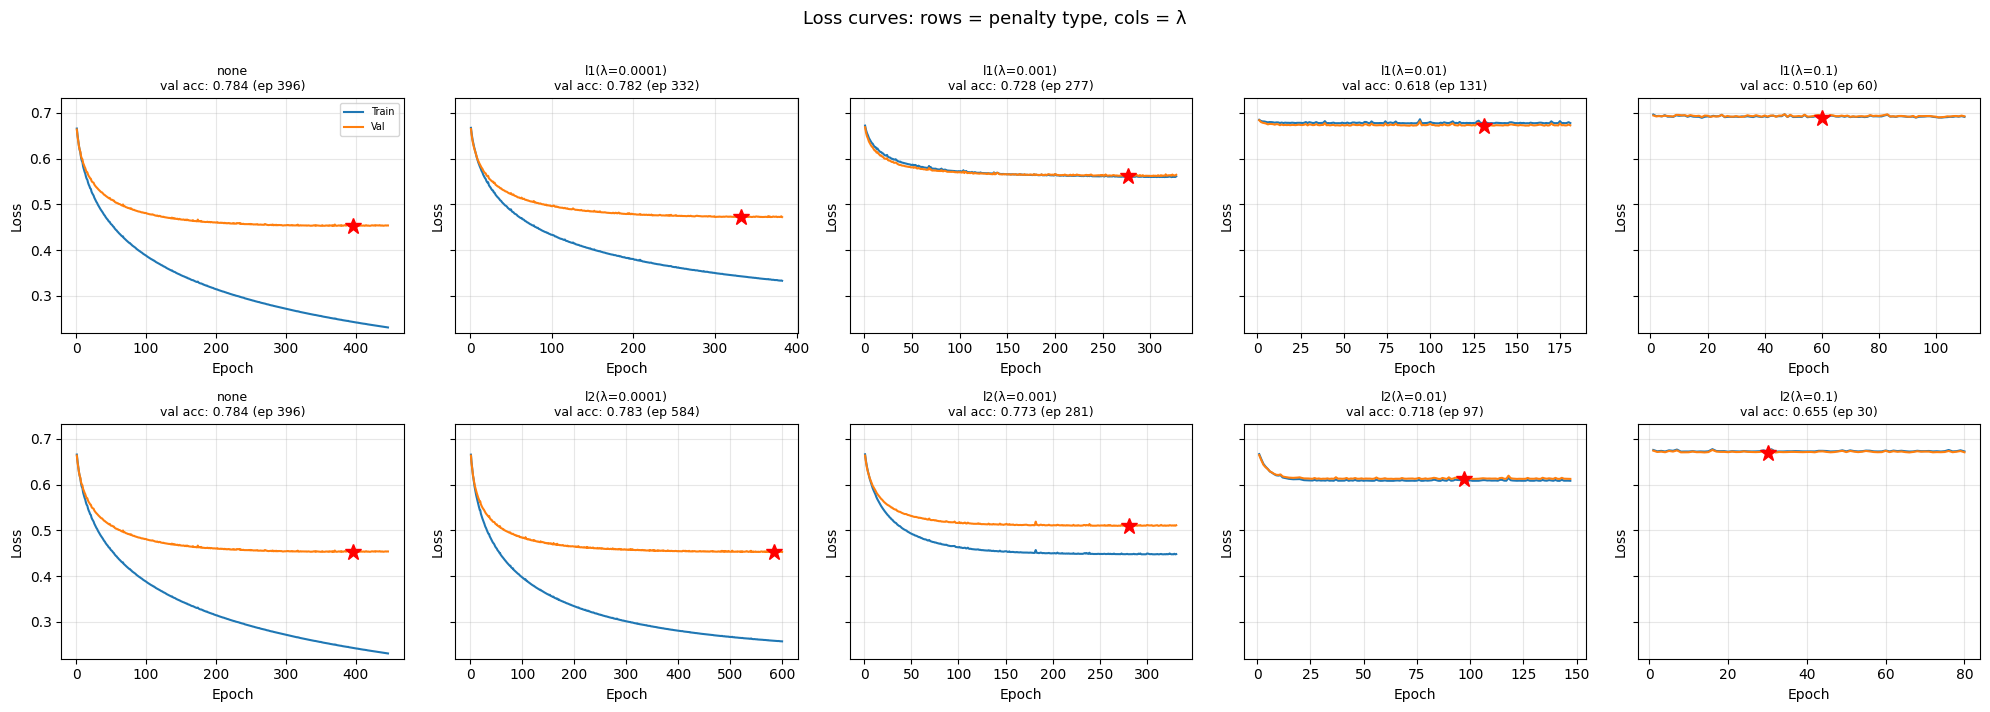

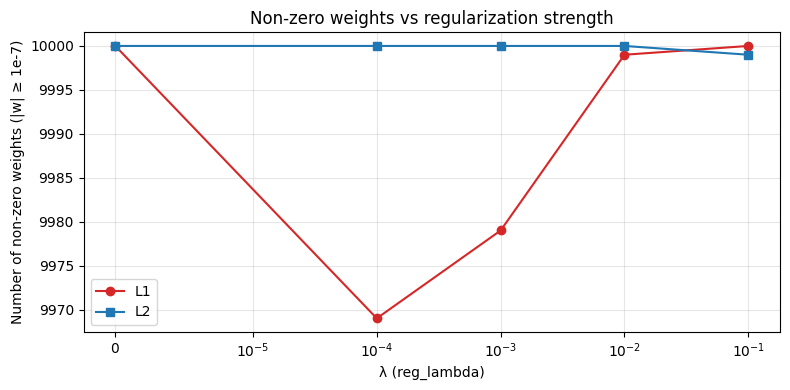

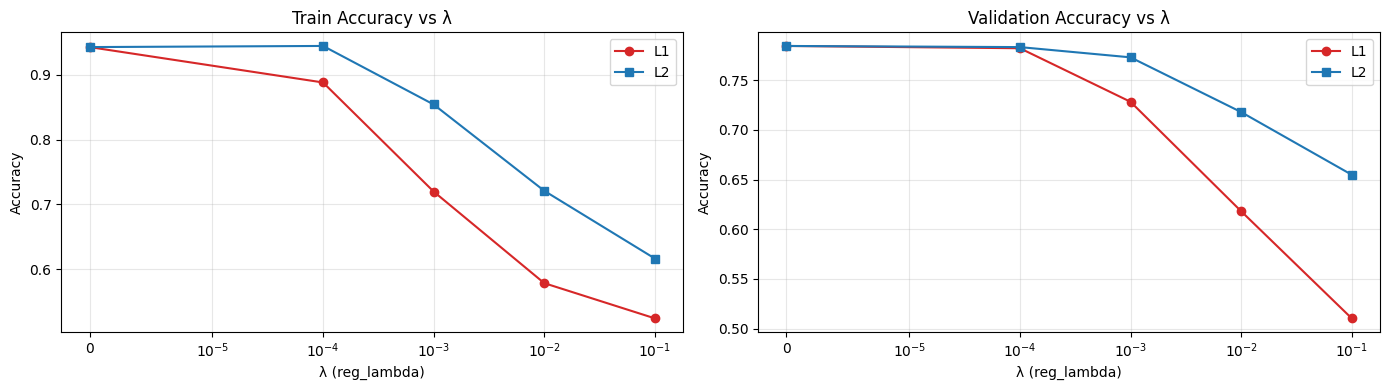

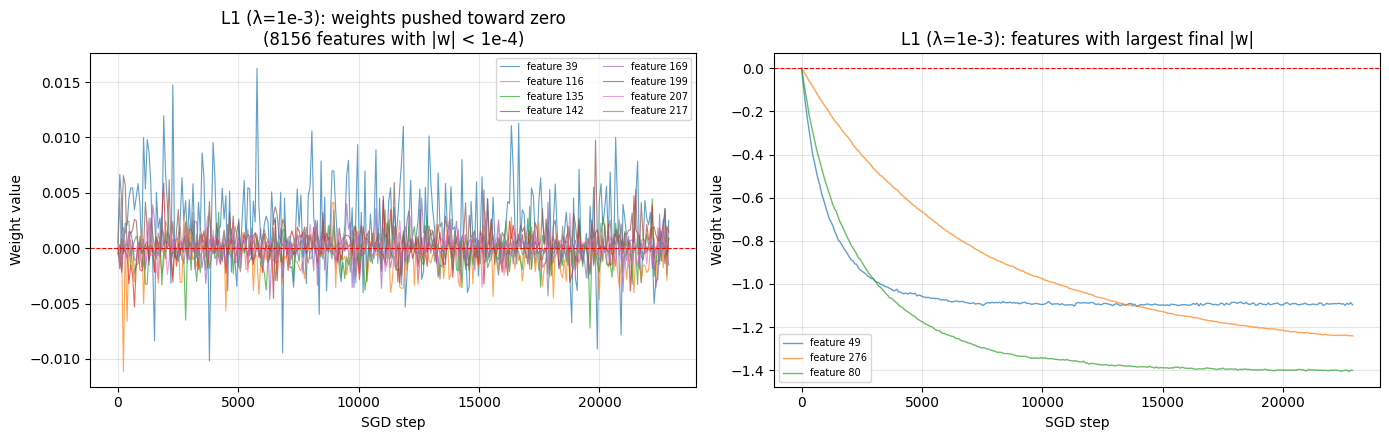

In [168]:
# Task 1.4 — Visualizations for λ sweep (Experiment 2)

lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
penalties_plot = ['l1', 'l2']

def penalty_for_lam(pen, lam):
    return ('none', 0.0) if lam == 0 else (pen, lam)

# --- Plot 0: Loss curves grid — rows = penalty, cols = λ ---
all_l = []
for pen in penalties_plot:
    for lam in lambdas:
        key = ('zeros', *penalty_for_lam(pen, lam))
        for e in l1_results[key]['epoch_log']:
            if not (np.isnan(e['train_loss']) or np.isnan(e['val_loss'])):
                all_l.extend([e['train_loss'], e['val_loss']])
yl = (min(all_l) * 0.95, max(all_l) * 1.05)

fig, axes = plt.subplots(len(penalties_plot), len(lambdas),
                         figsize=(4 * len(lambdas), 3.5 * len(penalties_plot)),
                         sharey=True)

for i, pen in enumerate(penalties_plot):
    for j, lam in enumerate(lambdas):
        ax = axes[i][j]
        key = ('zeros', *penalty_for_lam(pen, lam))
        log = l1_results[key]['epoch_log']
        eps = [e['epoch'] + 1 for e in log]
        val_losses = [e['val_loss'] for e in log]

        ax.plot(eps, [e['train_loss'] for e in log], color='tab:blue', label='Train')
        ax.plot(eps, val_losses, color='tab:orange', label='Val')

        valid = [(k, v) for k, v in enumerate(val_losses) if not np.isnan(v)]
        if valid:
            best_idx, best_vl = min(valid, key=lambda x: x[1])
            ax.plot(eps[best_idx], best_vl, '*', color='red', markersize=12, zorder=5)
            acc = log[best_idx]['val_metric']
            label_str = 'none' if lam == 0 else f'{pen}(λ={lam})'
            ax.set_title(f'{label_str}\nval acc: {float(acc):.3f} (ep {eps[best_idx]})', fontsize=9)

        ax.set_ylim(*yl)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

fig.suptitle('Loss curves: rows = penalty type, cols = λ', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Plot 1: Non-zero weights vs lambda ---
def get_best_metrics(results, init, penalty, reg_lam):
    res = results[(init, penalty, reg_lam)]
    log = res['epoch_log']
    val_losses = [e['val_loss'] for e in log]
    valid = [(k, v) for k, v in enumerate(val_losses) if not np.isnan(v)]
    if valid:
        best_idx, _ = min(valid, key=lambda x: x[1])
        return float(log[best_idx]['train_metric']), float(log[best_idx]['val_metric'])
    return float('nan'), float('nan')

fig, ax = plt.subplots(figsize=(8, 4))
for pen, color, marker in [('l1', 'tab:red', 'o'), ('l2', 'tab:blue', 's')]:
    n_nonzero = []
    for lam in lambdas:
        key = penalty_for_lam(pen, lam)
        w = l1_results[('zeros', *key)]['w']
        n_nonzero.append(int((np.abs(w) >= 1e-7).sum()))
    ax.plot(lambdas, n_nonzero, marker=marker, color=color, label=pen.upper())
ax.set_xscale('symlog', linthresh=1e-5)
ax.set_xlabel('λ (reg_lambda)')
ax.set_ylabel('Number of non-zero weights (|w| ≥ 1e-7)')
ax.set_title('Non-zero weights vs regularization strength')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Train & Val accuracy vs lambda ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for pen, color, marker in [('l1', 'tab:red', 'o'), ('l2', 'tab:blue', 's')]:
    train_accs, val_accs = [], []
    for lam in lambdas:
        key = penalty_for_lam(pen, lam)
        ta, va = get_best_metrics(l1_results, 'zeros', *key)
        train_accs.append(ta)
        val_accs.append(va)
    ax1.plot(lambdas, train_accs, marker=marker, color=color, label=pen.upper())
    ax2.plot(lambdas, val_accs, marker=marker, color=color, label=pen.upper())

for ax, title in [(ax1, 'Train Accuracy vs λ'), (ax2, 'Validation Accuracy vs λ')]:
    ax.set_xscale('symlog', linthresh=1e-5)
    ax.set_xlabel('λ (reg_lambda)')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 3: Weight dynamics for features eliminated by L1 ---
best_l1_key = ('zeros', 'l1', 1e-3)
res = l1_results[best_l1_key]
final_w = res['w']
history = res['history']

eliminated_idxs = np.where(np.abs(final_w) < 1e-4)[0]
large_idxs = np.argsort(np.abs(final_w))[-3:]

sample_every = max(1, len(history) // 300)
steps = list(range(0, len(history), sample_every))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

for idx in eliminated_idxs[:8]:
    w_trace = [history[s]['w'][idx].item() for s in steps]
    ax1.plot(steps, w_trace, alpha=0.7, linewidth=0.8, label=f'feature {idx}')
ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax1.set_xlabel('SGD step')
ax1.set_ylabel('Weight value')
ax1.set_title(f'L1 (λ=1e-3): weights pushed toward zero\n({len(eliminated_idxs)} features with |w| < 1e-4)')
ax1.legend(fontsize=7, ncol=2)
ax1.grid(True, alpha=0.3)

for idx in large_idxs:
    w_trace = [history[s]['w'][idx].item() for s in steps]
    ax2.plot(steps, w_trace, alpha=0.7, linewidth=1.0, label=f'feature {idx}')
ax2.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax2.set_xlabel('SGD step')
ax2.set_ylabel('Weight value')
ax2.set_title('L1 (λ=1e-3): features with largest final |w|')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (3 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [162]:
import torch
import matplotlib.pyplot as plt

# Convex bowl
def bowl(theta):
    x, y = theta[0], theta[1]
    return x**2 + 2*y**2


# Camel function
def camel(theta):
    x, y = theta[0], theta[1]
    return (4 - 2.1 * x**2+ x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z), levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [163]:
def gradient_descent(f, theta0, lr=0.001, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        # TODO: compute loss
        loss = ...

        # TODO: compute gradients
        ...

        # TODO: update parameters
        with torch.no_grad():
            theta -= ...

        # reset gradients
        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: update velocity
            v = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: accumulate squared gradients
            G = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):
        loss = ...
        ...

        with torch.no_grad():
            # TODO: update moments
            m = ...
            v = ...

            # TODO: bias correction
            m_hat = ...
            v_hat = ...

            # TODO: update parameters
            theta -= ...

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

#Run experiments

theta0 = torch.tensor([-1.5, 1.5])

results_bowl = {
    "GD": gradient_descent(bowl, theta0, lr=...),
    "Momentum": momentum(bowl, theta0, lr=..., beta=...),
    "AdaGrad": adagrad(bowl, theta0, lr=...),
    "Adam": adam(bowl, theta0, lr=...)
}

results_camel = {
    "GD": gradient_descent(camel, theta0, lr=...),
    "Momentum": momentum(camel, theta0, lr=..., beta=...),
    "AdaGrad": adagrad(camel, theta0, lr=...),
    "Adam": adam(camel, theta0, lr=...)
}

/var/folders/34/75wshfs14_33bb0hg72ny5_h0000gn/T/ipykernel_89965/3819652168.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)


TypeError: unsupported operand type(s) for -=: 'Tensor' and 'ellipsis'

# Bonus. An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$